In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/seasonal_agriculture_performance_dataset (2).csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [2]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

None

In [3]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values in each column:")
print(missing_values[missing_values > 0])

Missing values in each column:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64


In [4]:
# Impute missing values with the median
for col in ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)

# Verify that there are no more missing values
print("Missing values after imputation:")
print(df.isnull().sum().sum())

Missing values after imputation:
0


/tmp/ipykernel_1101/2637707761.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)


In [6]:
display(df.describe())

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,4000.000000,4000.00000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,4000.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,600.922825,26.81890,63.210500,7.323050,6.701010,26.507150,120.250825,57.781850,104.760050,...,0.826138,5.242350,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,287.193381,3.81818,11.960834,1.121186,0.641461,6.678837,31.216452,17.015074,27.742681,...,0.101747,13.311549,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,371.575000,23.90000,54.775000,6.600000,6.260000,21.800000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,831.975000,29.60000,71.900000,8.100000,7.140000,31.200000,141.225000,69.400000,123.600000,...,0.910000,2.830000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


/tmp/ipykernel_1101/910773172.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Season', order=df['Season'].value_counts().index, palette='magma')


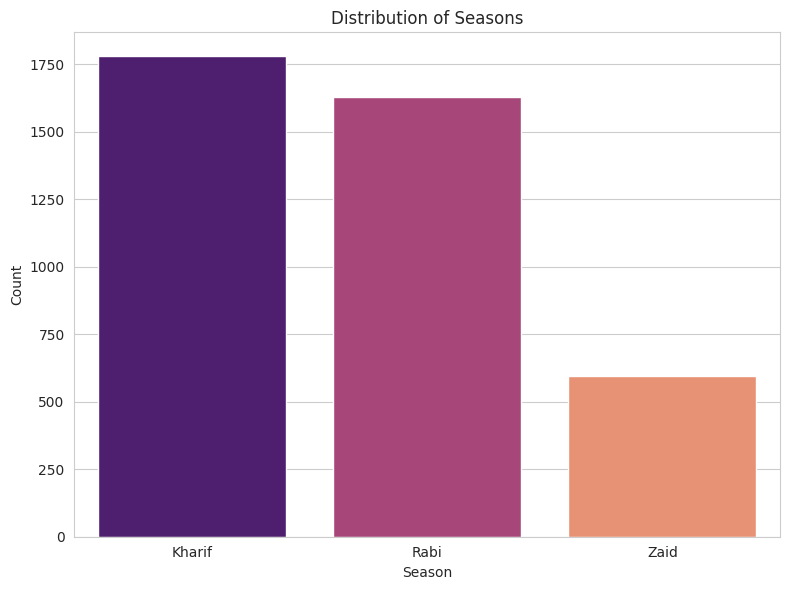

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Season', order=df['Season'].value_counts().index, palette='magma')
plt.title('Distribution of Seasons')
plt.xlabel('Season')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1101/2051387837.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Crop', order=df['Crop'].value_counts().index, palette='viridis')


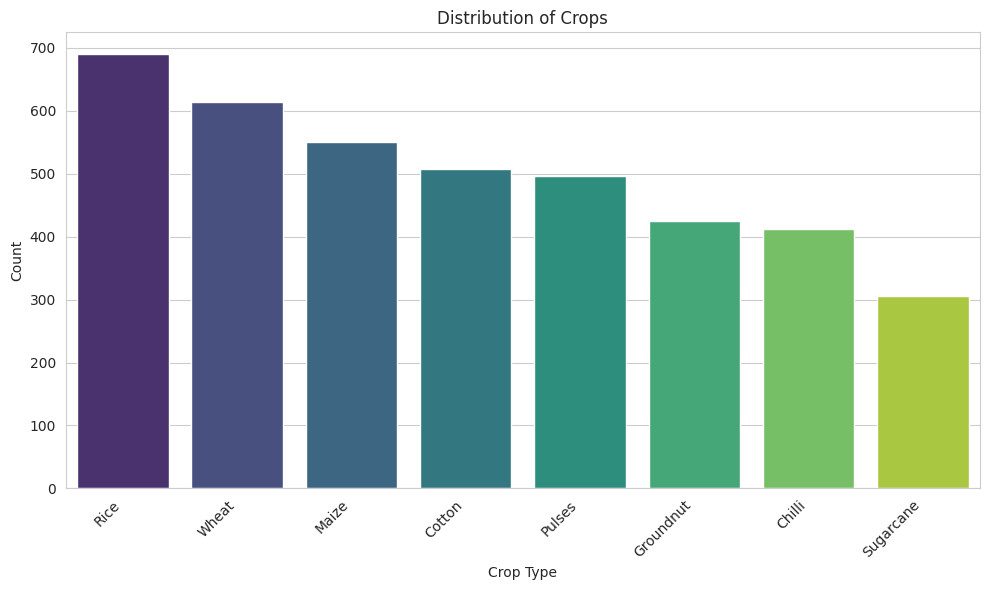

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Crop', order=df['Crop'].value_counts().index, palette='viridis')
plt.title('Distribution of Crops')
plt.xlabel('Crop Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

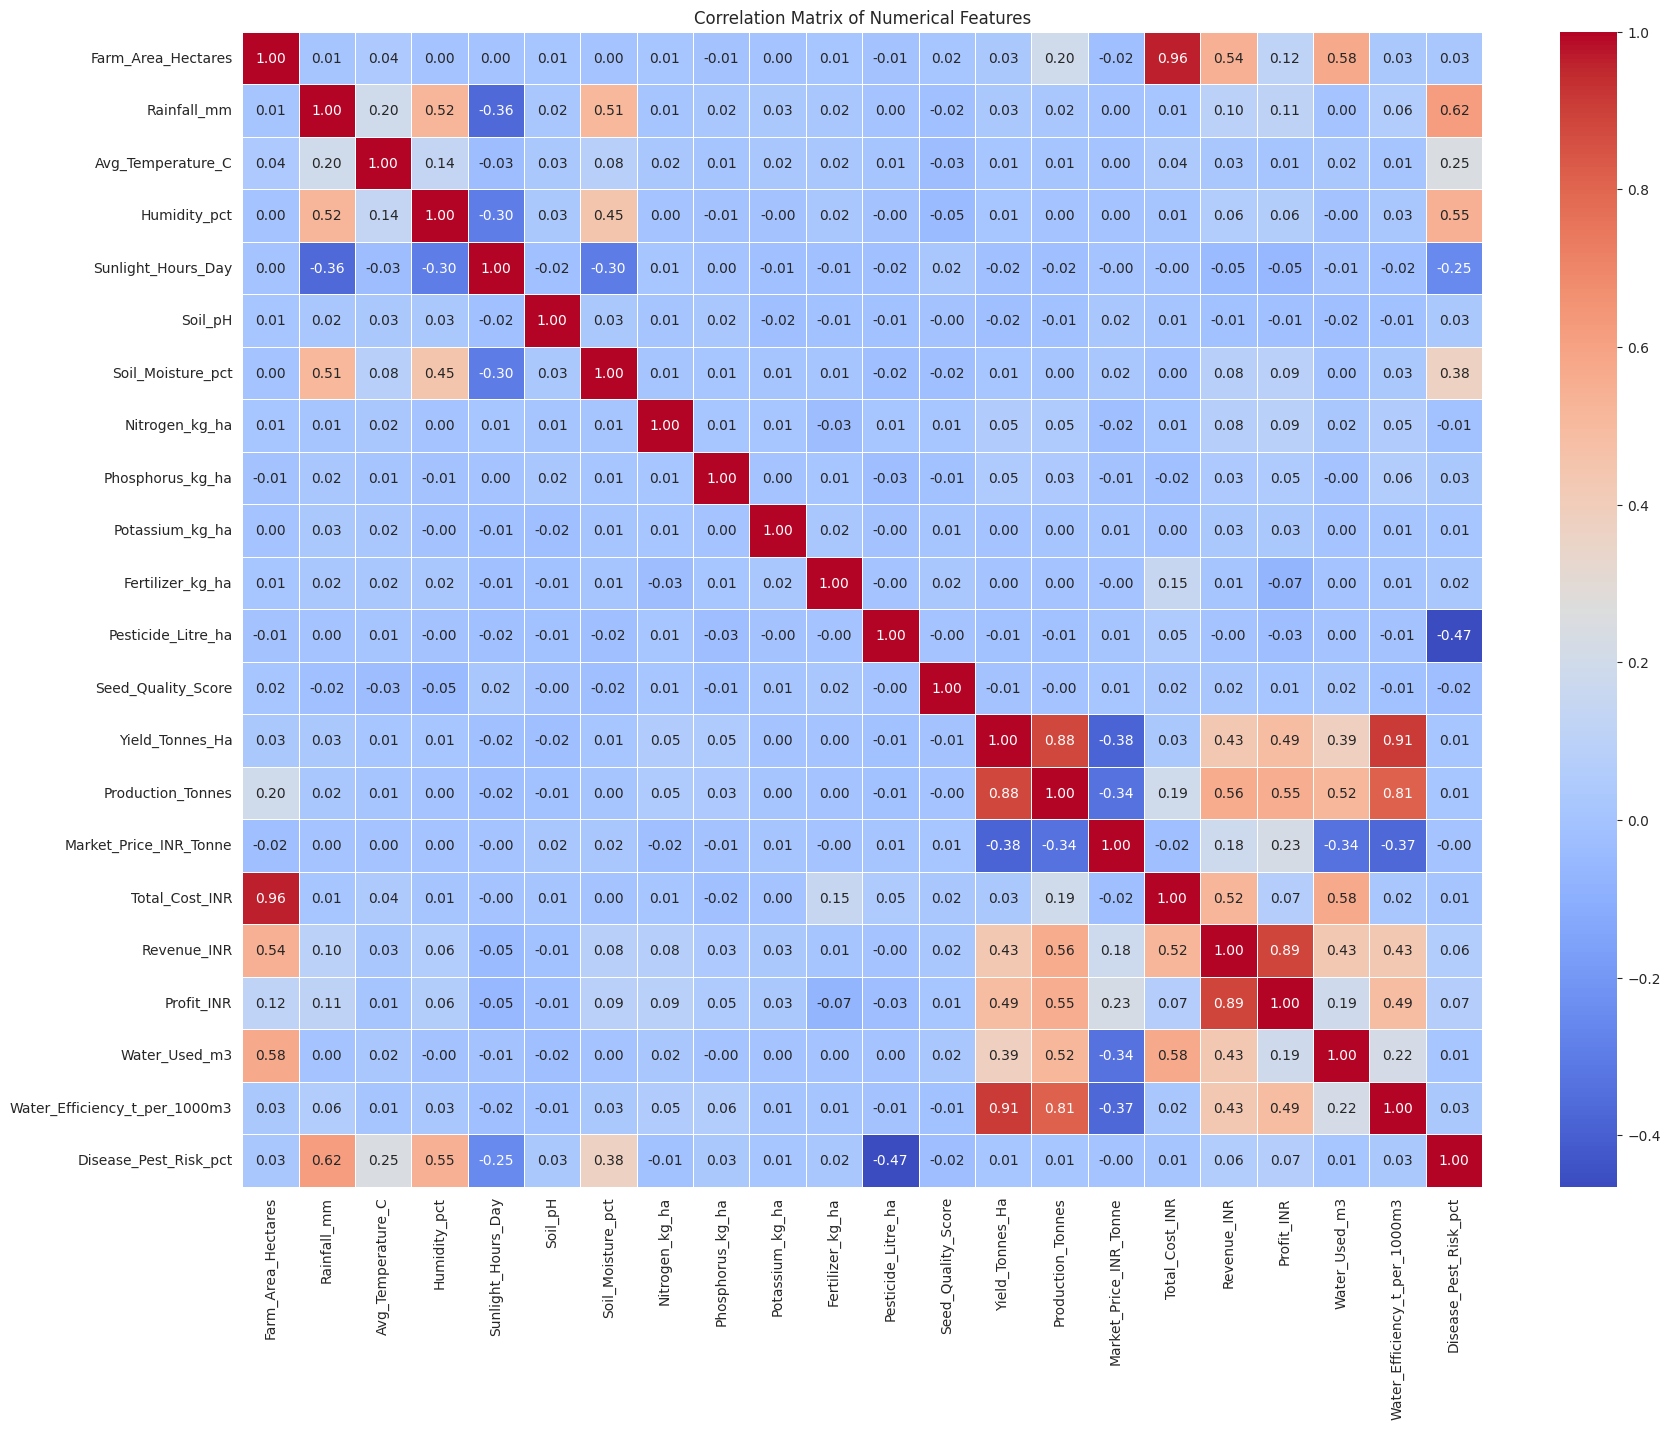

In [9]:
# Select numerical columns for correlation analysis
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
correlation_matrix = df[numerical_cols].corr()

# Plot the heatmap
plt.figure(figsize=(20, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

/tmp/ipykernel_1101/2156165878.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Crop', y='Yield_Tonnes_Ha', palette='viridis')


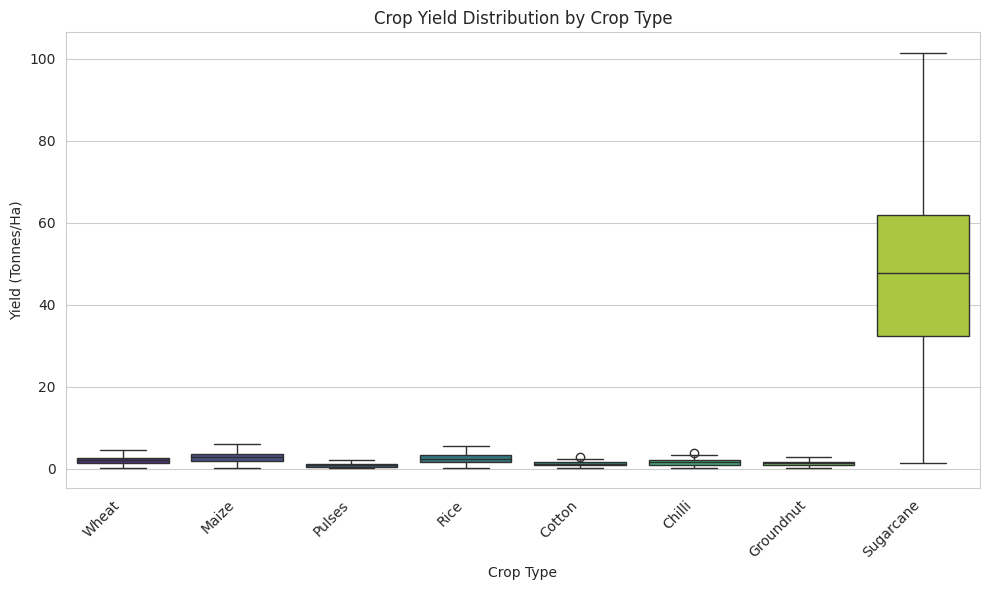

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Crop', y='Yield_Tonnes_Ha', palette='viridis')
plt.title('Crop Yield Distribution by Crop Type')
plt.xlabel('Crop Type')
plt.ylabel('Yield (Tonnes/Ha)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1101/253300217.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Crop', y='Profit_INR', palette='magma')


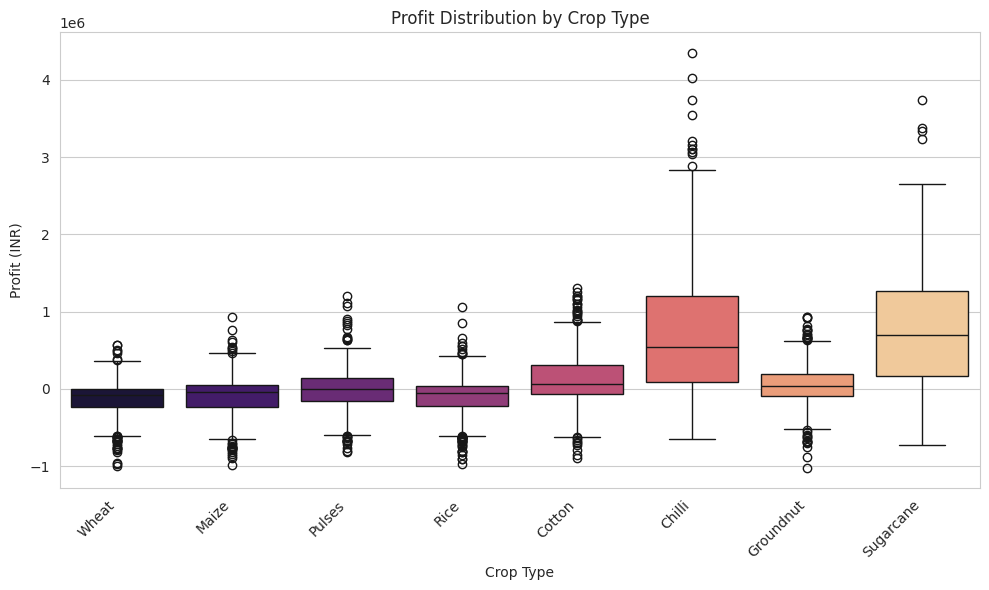

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Crop', y='Profit_INR', palette='magma')
plt.title('Profit Distribution by Crop Type')
plt.xlabel('Crop Type')
plt.ylabel('Profit (INR)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

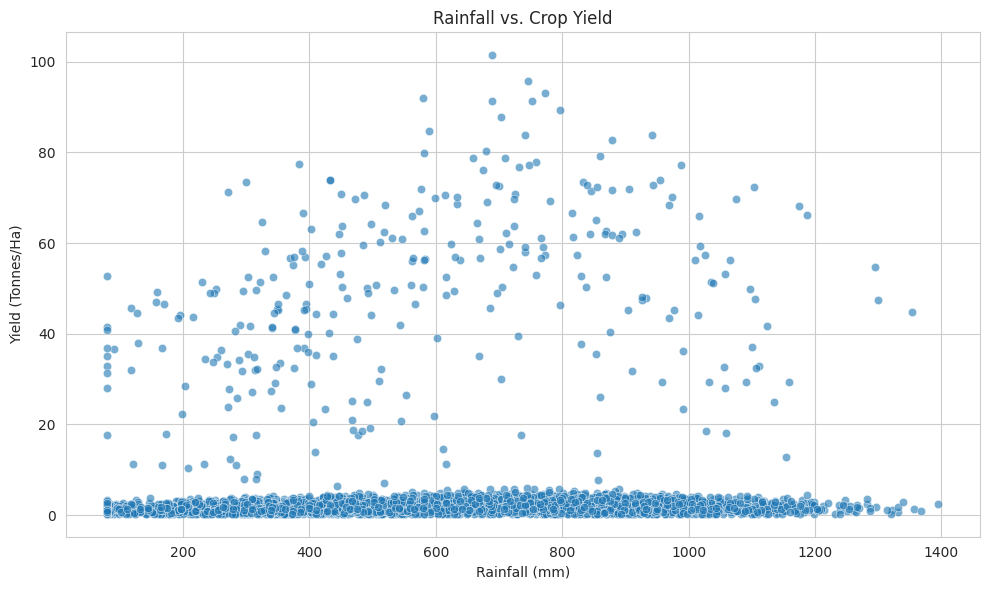

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Rainfall_mm', y='Yield_Tonnes_Ha', alpha=0.6)
plt.title('Rainfall vs. Crop Yield')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.tight_layout()
plt.show()

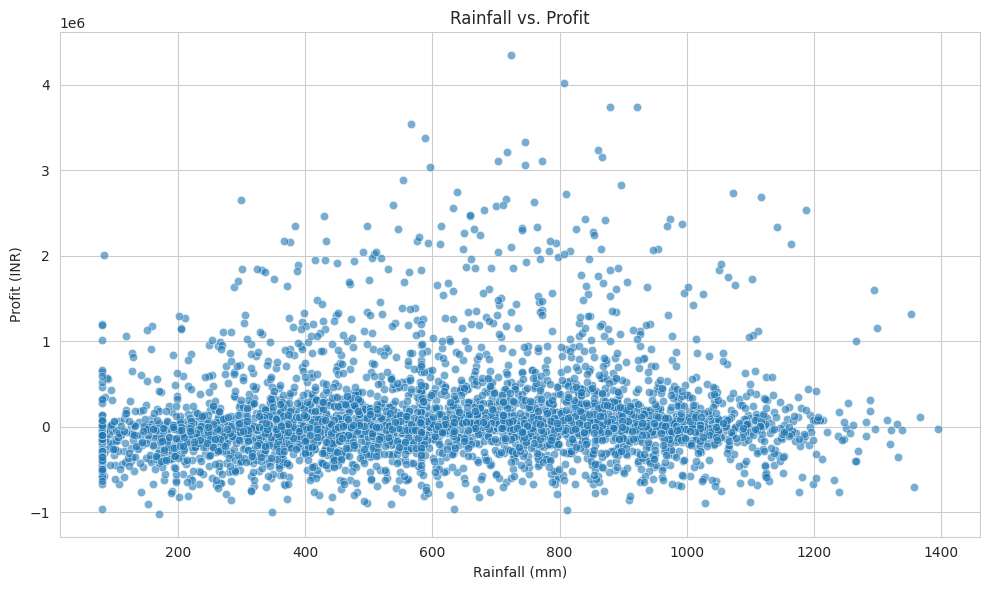

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Rainfall_mm', y='Profit_INR', alpha=0.6)
plt.title('Rainfall vs. Profit')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Profit (INR)')
plt.tight_layout()
plt.show()

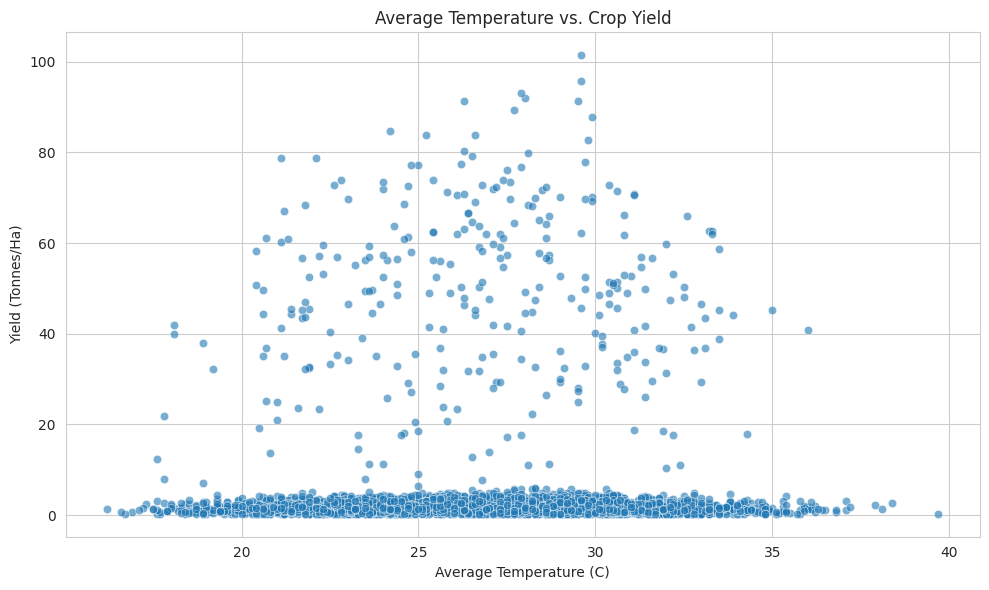

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Avg_Temperature_C', y='Yield_Tonnes_Ha', alpha=0.6)
plt.title('Average Temperature vs. Crop Yield')
plt.xlabel('Average Temperature (C)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.tight_layout()
plt.show()

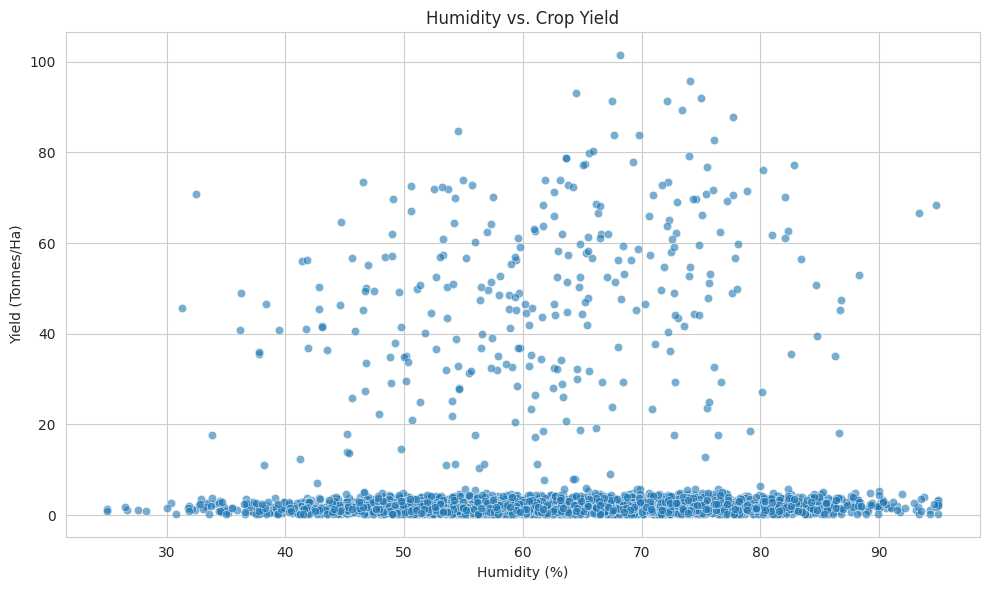

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Humidity_pct', y='Yield_Tonnes_Ha', alpha=0.6)
plt.title('Humidity vs. Crop Yield')
plt.xlabel('Humidity (%)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.tight_layout()
plt.show()

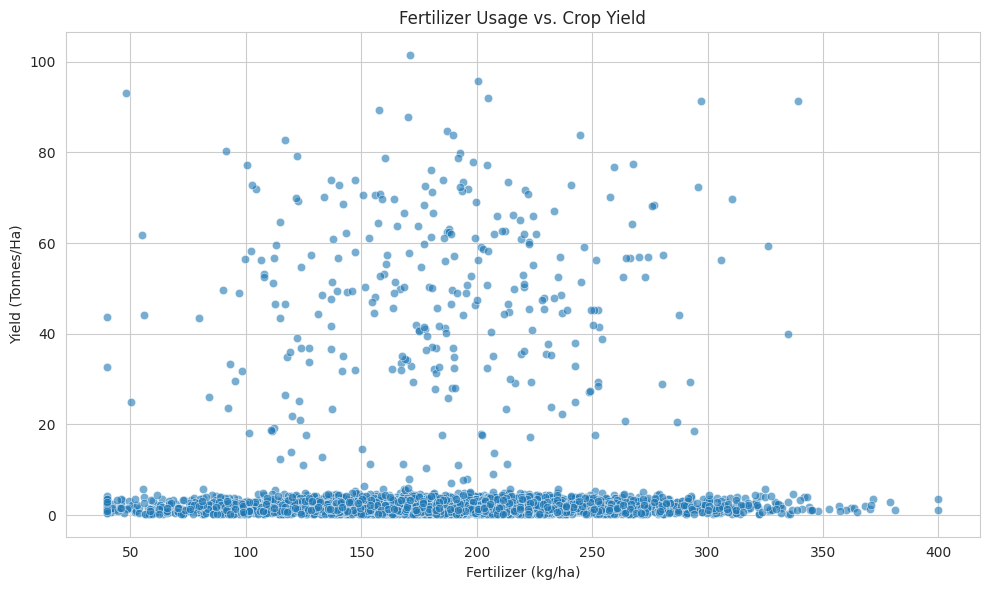

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Fertilizer_kg_ha', y='Yield_Tonnes_Ha', alpha=0.6)
plt.title('Fertilizer Usage vs. Crop Yield')
plt.xlabel('Fertilizer (kg/ha)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.tight_layout()
plt.show()

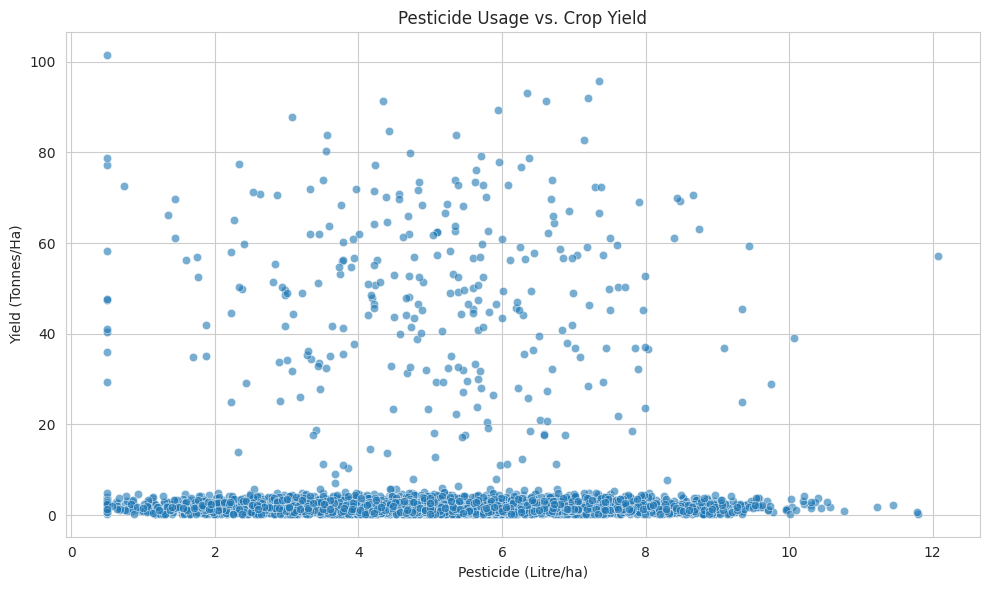

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Pesticide_Litre_ha', y='Yield_Tonnes_Ha', alpha=0.6)
plt.title('Pesticide Usage vs. Crop Yield')
plt.xlabel('Pesticide (Litre/ha)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.tight_layout()
plt.show()

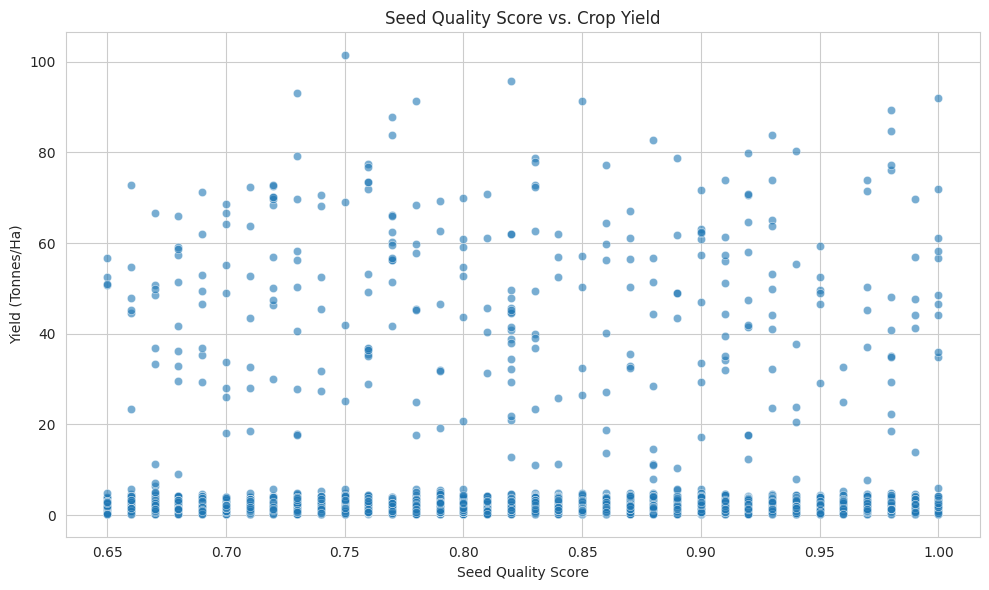

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Seed_Quality_Score', y='Yield_Tonnes_Ha', alpha=0.6)
plt.title('Seed Quality Score vs. Crop Yield')
plt.xlabel('Seed Quality Score')
plt.ylabel('Yield (Tonnes/Ha)')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1101/2191270860.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', palette='viridis')


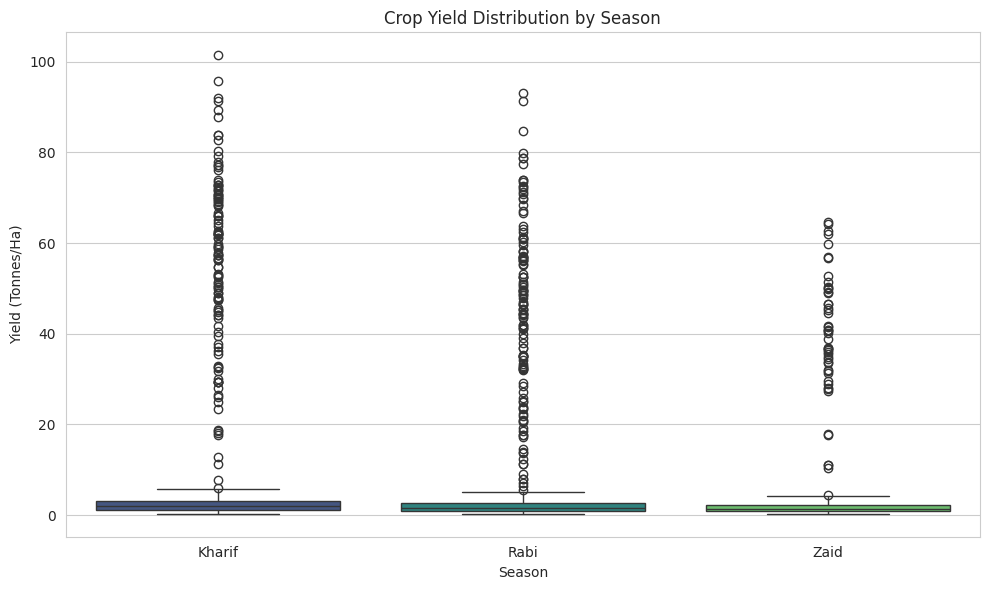

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', palette='viridis')
plt.title('Crop Yield Distribution by Season')
plt.xlabel('Season')
plt.ylabel('Yield (Tonnes/Ha)')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1101/2005648016.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y='Profit_INR', palette='magma')


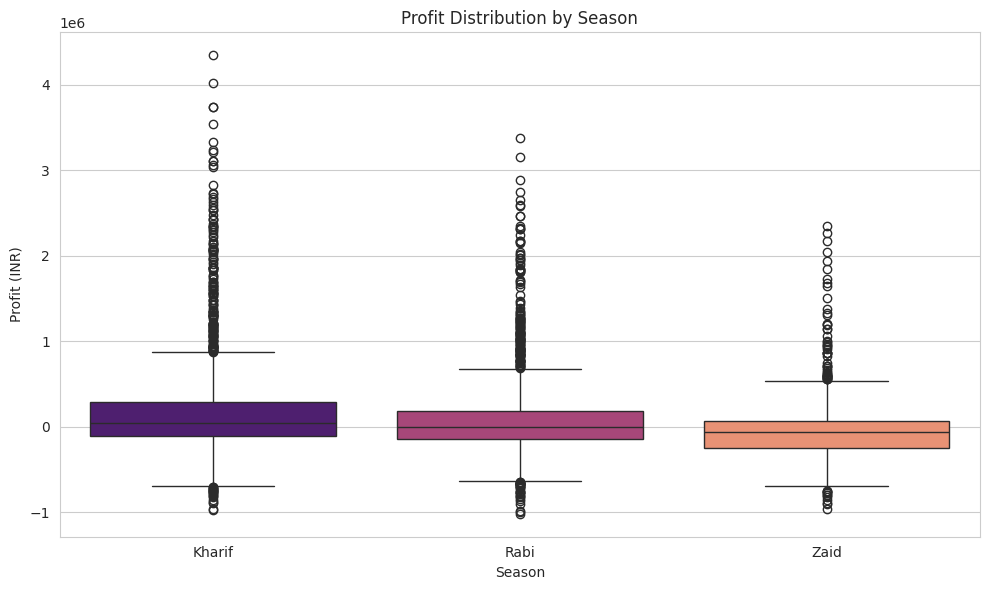

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Season', y='Profit_INR', palette='magma')
plt.title('Profit Distribution by Season')
plt.xlabel('Season')
plt.ylabel('Profit (INR)')
plt.tight_layout()
plt.show()

In [27]:
import pandas as pd

# Group by Season for Yield and Profit
seasonal_performance = df.groupby('Season')[['Yield_Tonnes_Ha', 'Profit_INR']].median().reset_index()
display(seasonal_performance)

# Group by Season for Environmental Characteristics
seasonal_environmental = df.groupby('Season')[['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct']].median().reset_index()
display(seasonal_environmental)

# Group by Season for Resource Usage
seasonal_resources = df.groupby('Season')[['Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Water_Used_m3']].median().reset_index()
display(seasonal_resources)

# Top Crop per Season
top_crop_per_season = df.groupby('Season')['Crop'].apply(lambda x: x.mode()[0]).reset_index()
display(top_crop_per_season)



,Season,Yield_Tonnes_Ha,Profit_INR
0,Kharif,1.94,38808.0
1,Rabi,1.67,-3187.0
2,Zaid,1.46,-62144.0


,Season,Rainfall_mm,Avg_Temperature_C,Humidity_pct
0,Kharif,853.1,28.5,71.90
1,Rabi,432.2,23.5,58.10
2,Zaid,288.2,31.0,52.35


,Season,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Used_m3
0,Kharif,188.20,5.180,4469.0
1,Rabi,185.30,5.020,4292.0
2,Zaid,183.95,5.185,4805.0


,Season,Crop
0,Kharif,Rice
1,Rabi,Rice
2,Zaid,Rice


### Observations and Answers:

1.  **How does agricultural performance vary across seasons?**
    *   **Yield (Median Tonnes/Ha):**
        *   Kharif: 1.94
        *   Rabi: 1.67
        *   Zaid: 1.46
    *   **Profit (Median INR):**
        *   Kharif: 38808.0
        *   Rabi: -3187.0
        *   Zaid: -62144.0
    *   **Observation:**


*   Kharif - Highest median yield and profit (most productive season).
*   Rabi - Lower median yield, operating at a loss.
*   Zaid - Lowest median yield, highly unprofitable (shows challenges or low-profit crops).

2.  **What major seasonal patterns can be observed?**
    *   **Observation:**
   

*   Kharif → Most productive and profitable season
*   Rabi → Less productive, unprofitable.
*   Zaid → Least productive, highly unprofitable.


3.  **Which characteristics change between seasons?**
    *   **Median Rainfall (mm):** Kharif (853.1) > Rabi (432.2) > Zaid (288.2)
    *   **Median Avg Temperature (C):** Zaid (31.0) > Kharif (28.5) > Rabi (23.5)
    *   **Median Humidity (pct):** Kharif (71.90) > Rabi (58.10) > Zaid (52.35)
    *   **Observation:**   


*   Kharif is characterized by high rainfall, moderate temperature, and high humidity.
*   Rabi is cooler and drier than Kharif, with moderate rainfall.
*   Zaid is the hottest season with the lowest rainfall and humidity.


4.  **What differences exist between agricultural activities in different seasons?**
    *   **Most Frequent Crop by Season:**
        *   Kharif: Rice
        *   Rabi: Rice
        *   Zaid: Rice
    *   **Observation:**

Rice - Most frequent crop across all three seasons (shows adaptability).

5.  **Are there noticeable variations in resource usage across seasons?**
    *   **Median Fertilizer (kg/ha):** Kharif (188.20) > Rabi (185.30) > Zaid (183.95)
    *   **Median Pesticide (Litre/ha):** Zaid (5.185) > Kharif (5.180) > Rabi (5.020)
    *   **Median Water Used (m3):** Zaid (4805.0) > Kharif (4469.0) > Rabi (4292.0)
    *   **Observation:**

*   Kharif - Highest median fertilizer usage.
*   Zaid - Slightly higher pesticide and water usage (likely due to hotter, drier conditions needing more irrigation and pest control).
*   Rabi -  Lower overall input usage compared to Kharif and Zaid.


6.  **Are there relationships between seasonal environmental conditions and agricultural performance?**
    *   **Observation:** Based on the scatter plots (Rainfall vs. Yield/Profit, Temperature vs. Yield, Humidity vs. Yield), there are observed relationships:
        *   **Rainfall:** High rainfall in Kharif coincides with high yields and profits. Lower rainfall in Rabi and Zaid correlates with reduced performance, suggesting rainfall is a critical factor.
        *   **Temperature:** Moderate average temperatures (around 28.5°C in Kharif) appear conducive to good yields, while higher temperatures in Zaid (31.0°C) with low humidity are associated with the lowest yields and significant losses.
        *   **Humidity:** Higher humidity in Kharif (71.90%) aligns with better performance, whereas lower humidity in Rabi (58.10%) and Zaid (52.35%) accompanies poorer outcomes. These factors are interconnected and significantly influence seasonal agricultural success.

7.  **How do economic outcomes vary across seasons?**
    *   **Observation:**

*   Kharif - Only season with positive median profit (₹38,808).
*   Rabi - Median loss (–₹3,187).
*   Zaid - Substantial median loss (–₹62,144).




8.  **Are there unusual or unexpected seasonal patterns?**
    *   **Observation:**

Box plots show significant outliers in yield and profit across seasons.

Rabi and Zaid have substantial median losses, likely due to environmental conditions.

Although Rice is the most frequent crop, it isn’t always profitable in Rabi and Zaid, suggesting other factors affect outcomes.

10. **What insights can be derived from the observed seasonal differences?**
    *   **Insights:**

Kharif -  Most agriculturally viable season (optimal rainfall, temperature, humidity).

Rabi - Less viable, financial losses despite Rice being frequent.

Zaid - Most challenging, lowest productivity and heavy losses.

Kharif is favorable, while Rabi and Zaid face major sustainability and profitability challenges.

11. **What conclusions can reasonably be drawn from the available data?**
    *   **Conclusion:**

Kharif - Highly productive and profitable (supported by favorable rainfall, temperature, humidity).

Rabi - Lower rainfall and different climate → lower yields, financial losses.

Zaid - Most challenging season → lowest yields, heavy losses.

Rice - Common crop, but profitability varies drastically by season.
Agricultural success depends heavily on seasonal conditions, with Kharif thriving and Rabi/Zaid struggling despite Rice being frequent.

12. **How could the findings support better seasonal agricultural planning?**
    *   **Planning Implications:** Farmers and agricultural planners can leverage these insights by:
        *   **Optimizing Crop Selection:**
         Re-evaluate choices for Rabi & Zaid; consider resilient alternatives or Rice varieties better suited to those conditions..
        *   **Resource Management:** Developing more efficient irrigation and input management strategies for drier and hotter seasons (Rabi and Zaid) to mitigate losses. During Kharif, focus can be on maximizing yield with abundant water.
        *   **Risk Mitigation:** Adopt drought-resistant crops, insurance, or other safeguards for Rabi & Zaid.
        *   **Policy & Support:** Provide incentives, support, or research for farmers in challenging seasons.